Strategy 1: 28,379 | Strategy 2: 30,000
Training ViT — 100px
Train: 21,000 | Val:   4,500 | Test:  2,879


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 01/30 | Train Loss: 0.4858 | Train Acc: 0.8230 | Val Loss: 0.3592 | Val Acc: 0.8913 | Time: 398.4s
   Best model saved (val F1: 0.8912)
Epoch 02/30 | Train Loss: 0.3807 | Train Acc: 0.8770 | Val Loss: 0.3502 | Val Acc: 0.8889 | Time: 411.8s
Epoch 03/30 | Train Loss: 0.3644 | Train Acc: 0.8840 | Val Loss: 0.3093 | Val Acc: 0.9100 | Time: 413.6s
   Best model saved (val F1: 0.9096)
Epoch 04/30 | Train Loss: 0.3608 | Train Acc: 0.8847 | Val Loss: 0.3293 | Val Acc: 0.8940 | Time: 413.9s
Epoch 05/30 | Train Loss: 0.3456 | Train Acc: 0.8892 | Val Loss: 0.3071 | Val Acc: 0.9047 | Time: 414.4s
Epoch 06/30 | Train Loss: 0.3338 | Train Acc: 0.8954 | Val Loss: 0.3124 | Val Acc: 0.9111 | Time: 413.5s
   Best model saved (val F1: 0.9105)
Epoch 07/30 | Train Loss: 0.3276 | Train Acc: 0.8999 | Val Loss: 0.3121 | Val Acc: 0.9013 | Time: 414.3s
Epoch 08/30 | Train Loss: 0.3251 | Train Acc: 0.8997 | Val Loss: 0.2947 | Val Acc: 0.9204 | Time: 413.2s
   Best model saved (val F1: 0.9205)
Epoch 09/30 

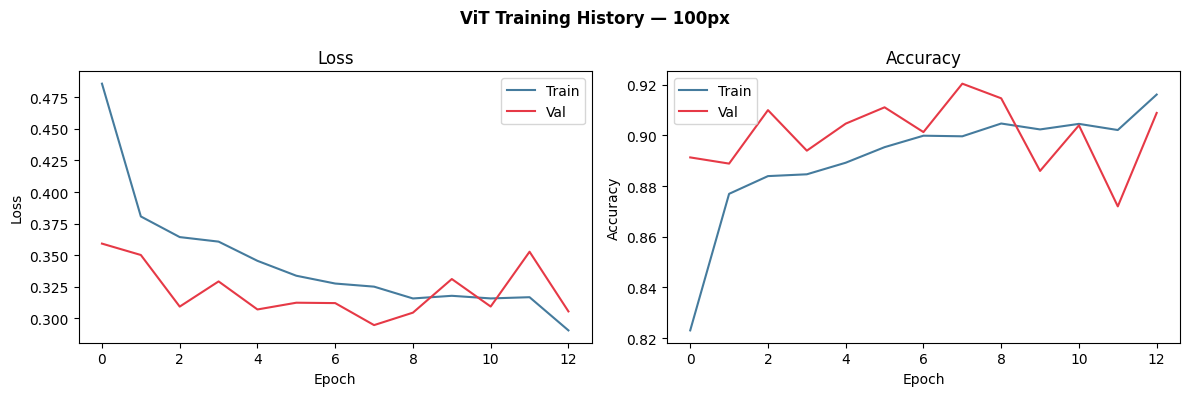

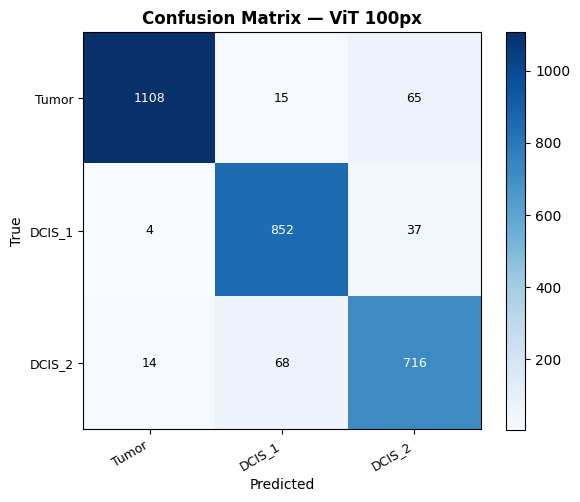

Training ViT — 50px
Train: 21,000 | Val:   4,500 | Test:  2,879
Epoch 01/30 | Train Loss: 0.6316 | Train Acc: 0.7392 | Val Loss: 0.6118 | Val Acc: 0.7769 | Time: 410.5s
   Best model saved (val F1: 0.7735)
Epoch 02/30 | Train Loss: 0.4831 | Train Acc: 0.8250 | Val Loss: 0.6058 | Val Acc: 0.7380 | Time: 412.9s
Epoch 03/30 | Train Loss: 0.4649 | Train Acc: 0.8317 | Val Loss: 0.4212 | Val Acc: 0.8591 | Time: 412.7s
   Best model saved (val F1: 0.8600)
Epoch 04/30 | Train Loss: 0.4433 | Train Acc: 0.8450 | Val Loss: 0.4461 | Val Acc: 0.8473 | Time: 413.7s
Epoch 05/30 | Train Loss: 0.4251 | Train Acc: 0.8505 | Val Loss: 0.4029 | Val Acc: 0.8691 | Time: 412.8s
   Best model saved (val F1: 0.8696)
Epoch 06/30 | Train Loss: 0.4146 | Train Acc: 0.8566 | Val Loss: 0.3868 | Val Acc: 0.8724 | Time: 412.6s
   Best model saved (val F1: 0.8716)
Epoch 07/30 | Train Loss: 0.4014 | Train Acc: 0.8637 | Val Loss: 0.3869 | Val Acc: 0.8769 | Time: 412.4s
   Best model saved (val F1: 0.8768)
Epoch 08/30 | Tr

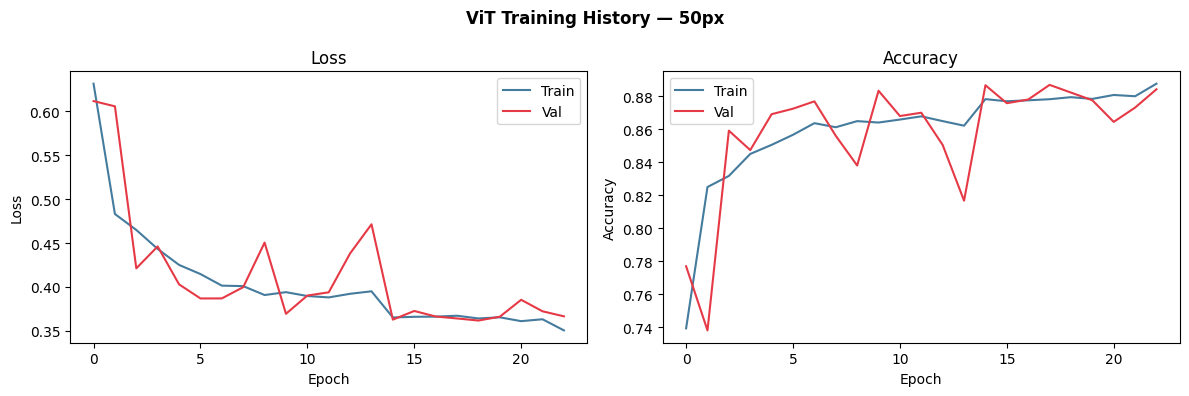

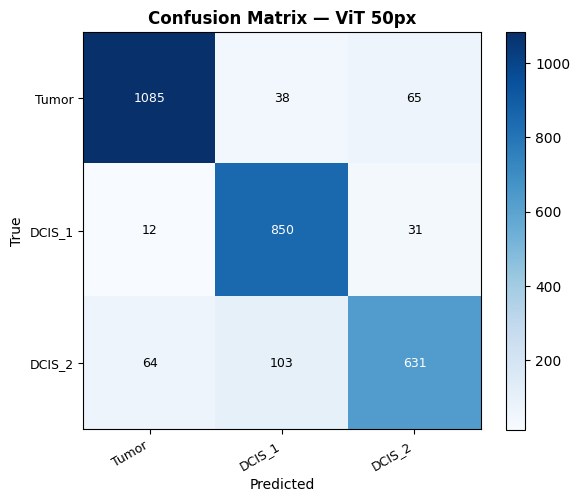

Training ViT — masked
Train: 21,000 | Val:   4,500 | Test:  4,500
Epoch 01/30 | Train Loss: 0.7588 | Train Acc: 0.6714 | Val Loss: 0.6065 | Val Acc: 0.7640 | Time: 407.4s
   Best model saved (val F1: 0.7617)
Epoch 02/30 | Train Loss: 0.6500 | Train Acc: 0.7340 | Val Loss: 0.6774 | Val Acc: 0.7311 | Time: 408.7s
Epoch 03/30 | Train Loss: 0.6180 | Train Acc: 0.7520 | Val Loss: 0.5685 | Val Acc: 0.7884 | Time: 409.9s
   Best model saved (val F1: 0.7873)
Epoch 04/30 | Train Loss: 0.5984 | Train Acc: 0.7618 | Val Loss: 0.5507 | Val Acc: 0.7913 | Time: 410.3s
   Best model saved (val F1: 0.7916)
Epoch 05/30 | Train Loss: 0.5800 | Train Acc: 0.7699 | Val Loss: 0.5364 | Val Acc: 0.8064 | Time: 410.1s
   Best model saved (val F1: 0.8040)
Epoch 06/30 | Train Loss: 0.5676 | Train Acc: 0.7777 | Val Loss: 0.5809 | Val Acc: 0.7713 | Time: 410.1s
Epoch 07/30 | Train Loss: 0.5627 | Train Acc: 0.7818 | Val Loss: 0.5375 | Val Acc: 0.7960 | Time: 410.7s
Epoch 08/30 | Train Loss: 0.5504 | Train Acc: 0.787

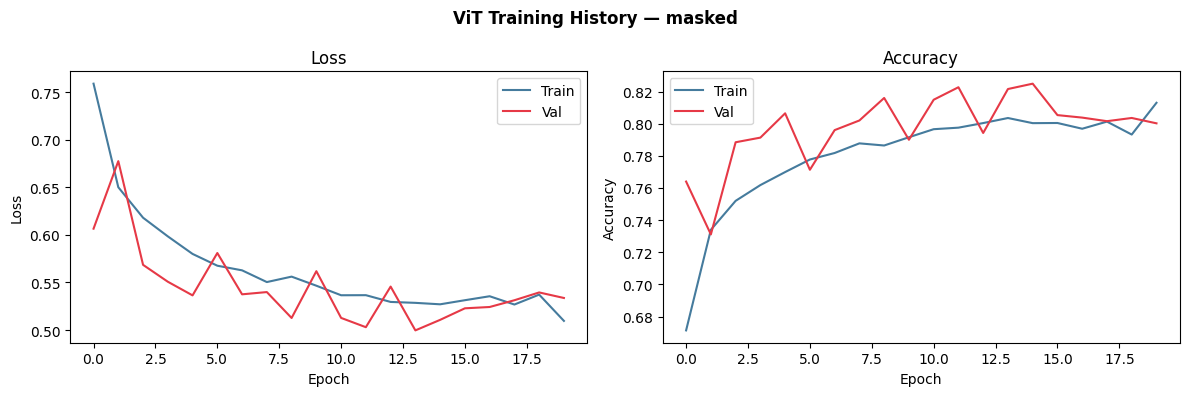

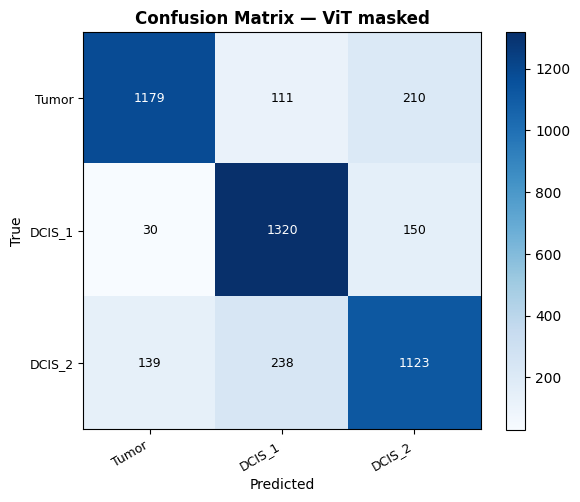


FINAL COMPARISON (ViT): 100px vs 50px vs masked
Metric                    100px       50px     masked
test_macro_f1            0.9253     0.8846     0.8047
test_accuracy            0.9295     0.8913     0.8049
test_loss                0.2647     0.3388     0.5286
cohen_kappa              0.8930     0.8345     0.7073


In [1]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import (f1_score, accuracy_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
warnings.filterwarnings('ignore')

# CONFIG
PREPROCESSED_DIR = '/kaggle/input/datasets/eva233333/data3888-preprocessing2/'
OUT_DIR          = '/kaggle/working/'

SEED        = 42
NUM_EPOCHS  = 30
PATIENCE    = 5
BATCH_SIZE  = 32        
NUM_CLASSES = 3
IMG_SIZE    = 224       # Use 224 uniformly.
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LR_HEAD     = 3e-4
LR_BLOCKS   = 3e-5     # ViT blocks

CLASS_NAMES = ['Tumor', 'DCIS_1', 'DCIS_2']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# LOAD DATA
master_s1  = pd.read_csv(PREPROCESSED_DIR + 'master_labels_s1.csv')
master_s2  = pd.read_csv(PREPROCESSED_DIR + 'master_labels_s2.csv')
norm_stats = pd.read_csv(PREPROCESSED_DIR + 'norm_stats.csv')
MEAN       = norm_stats['mean'].tolist()
STD        = norm_stats['std'].tolist()

print(f"Strategy 1: {len(master_s1):,} | Strategy 2: {len(master_s2):,}")


# DATASET
MASK_KEEP_RATIO = 0.30
MASK_FILL       = np.array([123, 116, 103], dtype=np.uint8)

def apply_mask(img):
    arr    = np.array(img)
    h, w   = arr.shape[:2]
    cx, cy = w // 2, h // 2
    radius = int(min(h, w) * MASK_KEEP_RATIO)
    Y, X   = np.ogrid[:h, :w]
    inside = (X - cx) ** 2 + (Y - cy) ** 2 <= radius ** 2
    result = np.full_like(arr, fill_value=MASK_FILL)
    result[inside] = arr[inside]
    return Image.fromarray(result)

def get_transforms(is_train=False):
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])


class CellDataset(Dataset):
    def __init__(self, df, split, use_100px=True, use_masked=False):
        self.df         = df[df['split'] == split].reset_index(drop=True)
        self.use_masked = use_masked
        self.path_col   = 'path_100' if use_100px else 'path_50'
        self.transform  = get_transforms()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[self.path_col]).convert('RGB')
        if self.use_masked:
            img = apply_mask(img)
        img   = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label


def get_dataloaders(master_df, use_100px=True, use_masked=False):
    train_ds = CellDataset(master_df, 'train', use_100px, use_masked)
    val_ds   = CellDataset(master_df, 'val',   use_100px, use_masked)
    test_ds  = CellDataset(master_df, 'test',  use_100px, use_masked)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


# MODEL — ViT
def build_vit():
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=NUM_CLASSES,
    )
    # Freeze all layers except the last two Transformer blocks and the classification head.
    for param in model.parameters():
        param.requires_grad = False
    # Thaw the last two blocks
    for block in model.blocks[-2:]:
        for param in block.parameters():
            param.requires_grad = True
    # Thawing classification head
    for param in model.head.parameters():
        param.requires_grad = True
    # Thaw the norm layer
    for param in model.norm.parameters():
        param.requires_grad = True
    return model.to(DEVICE)


def get_vit_optimizer(model):
    block_params = []
    for block in model.blocks[-2:]:
        block_params.extend(list(block.parameters()))
    norm_params = list(model.norm.parameters())
    head_params = list(model.head.parameters())
    return torch.optim.Adam([
        {'params': block_params + norm_params, 'lr': LR_BLOCKS},
        {'params': head_params,                'lr': LR_HEAD},
    ], weight_decay=1e-2)


# TRAINING AND EVALUATION
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels


# MAIN TRAINING LOOP
def train_vit(master_df, use_100px=True, use_masked=False, tag=None):
    if tag is None:
        tag = 'masked' if use_masked else ('100px' if use_100px else '50px')

    print(f"Training ViT — {tag}")

    train_loader, val_loader, test_loader = get_dataloaders(
        master_df, use_100px, use_masked)
    print(f"Train: {len(train_loader.dataset):,} | "
          f"Val:   {len(val_loader.dataset):,} | "
          f"Test:  {len(test_loader.dataset):,}")

    model     = build_vit()
    optimizer = get_vit_optimizer(model)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

    best_val_f1     = 0.0
    patience_count  = 0
    best_model_path = OUT_DIR + f'vit_best_{tag}.pth'

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(
            model, val_loader, criterion)
        scheduler.step(val_f1)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {time.time()-t0:.1f}s")

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            patience_count = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   Best model saved (val F1: {best_val_f1:.4f})")
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}")
                break

    # Test evaluation
    model.load_state_dict(torch.load(best_model_path))
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion)
    kappa = cohen_kappa_score(test_labels, test_preds)

    print(f"\nTEST RESULTS (ViT — {tag})")
    print(f"  Test Loss:     {test_loss:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Macro F1: {test_f1:.4f}")
    print(f"  Cohen's Kappa: {kappa:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(test_labels, test_preds,
                                target_names=CLASS_NAMES,
                                zero_division=0))

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'ViT Training History — {tag}', fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train', color='#457B9D')
    axes[0].plot(history['val_loss'],   label='Val',   color='#E63946')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss');   axes[0].legend()
    axes[1].plot(history['train_acc'], label='Train', color='#457B9D')
    axes[1].plot(history['val_acc'],   label='Val',   color='#E63946')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR + f'vit_history_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — ViT {tag}', fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR + f'vit_confusion_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    results = {
        'tag':           tag,
        'test_loss':     test_loss,
        'test_macro_f1': test_f1,
        'test_accuracy': test_acc,
        'cohen_kappa':   kappa,
    }
    pd.DataFrame([results]).to_csv(
        OUT_DIR + f'vit_results_{tag}.csv', index=False)

    return model, history, results


# RUN — three experiments
model_100,    history_100,    results_100    = train_vit(master_s1, use_100px=True,  use_masked=False, tag='100px')
model_50,     history_50,     results_50     = train_vit(master_s1, use_100px=False, use_masked=False, tag='50px')
model_masked, history_masked, results_masked = train_vit(master_s2, use_100px=True,  use_masked=True,  tag='masked')

# Final comparison
print("\nFINAL COMPARISON (ViT): 100px vs 50px vs masked")
print(f"{'Metric':<20} {'100px':>10} {'50px':>10} {'masked':>10}")
for key in ['test_macro_f1', 'test_accuracy', 'test_loss', 'cohen_kappa']:
    print(f"{key:<20} "
          f"{results_100[key]:>10.4f} "
          f"{results_50[key]:>10.4f} "
          f"{results_masked[key]:>10.4f}")